In [2]:

import pandas as pd
import numpy as np

In [3]:
#Customer_support table

# Load
Customer_support = pd.read_csv("/content/da_fitly_customer_support.csv")
print("Customer_support:", Customer_support.shape)

# Drop text column
Customer_support = Customer_support.drop(columns=["comments"], errors="ignore")

# ---- ticket_time: mm:ss.ms -> timedelta ----
Customer_support["ticket_time"] = Customer_support["ticket_time"].replace(
    r"^\s*$", pd.NA, regex=True
)

Customer_support["ticket_time"] = pd.to_timedelta(
    "00:" + Customer_support["ticket_time"].astype("string"),
    errors="coerce"
)

# ---- user_id: nullable integer ----
Customer_support["user_id"] = pd.to_numeric(
    Customer_support["user_id"], errors="coerce"
).astype("Int64")

# ---- channel: clean '-' and fill Unknown ----
Customer_support["channel"] = Customer_support["channel"].replace("-", pd.NA).astype("category")
Customer_support["channel"] = Customer_support["channel"].cat.add_categories(["Unknown"]).fillna("Unknown")

# ---- topic: category ----
Customer_support["topic"] = Customer_support["topic"].astype("category")

# ---- resolution_time_hours: float ----
Customer_support["resolution_time_hours"] = pd.to_numeric(
    Customer_support["resolution_time_hours"], errors="coerce"
)

# ---- state: convert 0/1 -> boolean ----
Customer_support["state"] = pd.to_numeric(Customer_support["state"], errors="coerce")
Customer_support["state"] = Customer_support["state"].map({1: True, 0: False})

# ---- Quality checks ----
print("Nulls per column:\n", Customer_support.isnull().sum())
print("Duplicates (full row):", Customer_support.duplicated().sum())

Customer_support.info()
Customer_support.head()


Customer_support: (918, 7)
Nulls per column:
 ticket_time              0
user_id                  0
channel                  0
topic                    0
resolution_time_hours    0
state                    0
dtype: int64
Duplicates (full row): 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   ticket_time            918 non-null    timedelta64[ns]
 1   user_id                918 non-null    Int64          
 2   channel                918 non-null    category       
 3   topic                  918 non-null    category       
 4   resolution_time_hours  918 non-null    float64        
 5   state                  918 non-null    bool           
dtypes: Int64(1), bool(1), category(2), float64(1), timedelta64[ns](1)
memory usage: 25.6 KB


,ticket_time,user_id,channel,topic,resolution_time_hours,state
0,0 days 00:55:17.200000,10125,chat,technical,11.48,True
1,0 days 00:21:54.500000,10109,chat,account,1.01,False
2,0 days 00:39:35.700000,10149,chat,technical,10.09,False
3,0 days 00:49:47,10268,phone,account,9.10,True
4,0 days 00:24:38.900000,10041,phone,other,2.28,True


In [5]:
# Customer Support and load and efficiency

# Tickets by channel
Customer_support["channel"].value_counts()


# Tickets by topic
Customer_support["topic"].value_counts()


# Avg resolution time
Customer_support["resolution_time_hours"].mean()

#High ticket volume or resolution time often correlates with churn.

Customer_support

,ticket_time,user_id,channel,topic,resolution_time_hours,state
0,0 days 00:55:17.200000,10125,chat,technical,11.48,True
1,0 days 00:21:54.500000,10109,chat,account,1.01,False
2,0 days 00:39:35.700000,10149,chat,technical,10.09,False
3,0 days 00:49:47,10268,phone,account,9.10,True
4,0 days 00:24:38.900000,10041,phone,other,2.28,True
...,...,...,...,...,...,...
913,0 days 00:09:46.300000,10225,chat,other,32.46,False
914,0 days 00:03:30.800000,10081,chat,account,4.98,False
915,0 days 00:17:13.100000,10373,chat,other,14.65,False
916,0 days 00:28:27.400000,10148,phone,billing,18.35,True


In [6]:
# Account Info


Account_Info = pd.read_csv("/content/da_fitly_account_info.csv")

# Clean customer_id
Account_Info["customer_id"] = (
    Account_Info["customer_id"]
    .str.replace("C", "", regex=False)
    .astype(int)
)

# Set correct data types
Account_Info = Account_Info.astype({
    "email": "string",
    "state": "string",
    "plan": "category",
    "churn_status": "string"
})

# Clean pricing column
Account_Info["plan_list_price"] = pd.to_numeric(
    Account_Info["plan_list_price"], errors="coerce"
).astype("Int64")

# Structural check
Account_Info.info()

# Statistical summary
Account_Info.describe()

# Missing values check
Account_Info.isnull().sum()

# Churn-specific validation
Account_Info["churn_status"].value_counts(dropna=False)

Account_Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   customer_id      400 non-null    int64   
 1   email            400 non-null    string  
 2   state            400 non-null    string  
 3   plan             400 non-null    category
 4   plan_list_price  400 non-null    Int64   
 5   churn_status     114 non-null    string  
dtypes: Int64(1), category(1), int64(1), string(3)
memory usage: 16.7 KB


,customer_id,email,state,plan,plan_list_price,churn_status
0,10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,10001,user10001@example.net,Louisiana,Basic,22,Y
2,10002,user10002@example.net,Oklahoma,Basic,24,<NA>
3,10003,user10003@example.com,Michigan,Free,0,<NA>
4,10004,user10004@example.com,Texas,Enterprise,119,<NA>
...,...,...,...,...,...,...
395,10395,user10395@example.org,Arizona,Free,0,<NA>
396,10396,user10396@example.net,Vermont,Free,0,<NA>
397,10397,user10397@example.net,Vermont,Free,0,Y
398,10398,user10398@example.net,Alabama,Enterprise,81,<NA>


In [7]:
#Account_Info Churn Analysis
# Customers by plan
Account_Info["plan"].value_counts()



# Churn distribution
Account_Info["churn_status"].value_counts(normalize=True) * 100



# Churn by plan
Account_Info.groupby("plan")["churn_status"].value_counts(normalize=True).unstack()

/tmp/ipython-input-4168022346.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Account_Info.groupby("plan")["churn_status"].value_counts(normalize=True).unstack()


churn_status,Y
plan,
Basic,1.0
Enterprise,1.0
Free,1.0
Pro,1.0


In [8]:
# User Activity

# Load
User_Activity = pd.read_csv("/content/da_fitly_user_activity.csv")
print("User_Activity:", User_Activity.shape)

# Convert event_time (mm:ss.ms) → timedelta
User_Activity["event_time"] = pd.to_timedelta(
    "00:" + User_Activity["event_time"].astype(str),
    errors="coerce"
)

# Ensure user_id is integer
User_Activity["user_id"] = pd.to_numeric(
    User_Activity["user_id"], errors="coerce"
).astype("Int64")

# Convert event_type to categorical
User_Activity["event_type"] = User_Activity["event_type"].astype("category")


User_Activity.head()

User_Activity.info()

User_Activity: (445, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   event_time  445 non-null    timedelta64[ns]
 1   user_id     445 non-null    Int64          
 2   event_type  445 non-null    category       
dtypes: Int64(1), category(1), timedelta64[ns](1)
memory usage: 8.2 KB


In [9]:
# User Activity Engagement Analysis

# Event distribution
User_Activity["event_type"].value_counts()


# Average session time per event
User_Activity.groupby("event_type")["event_time"].mean()

/tmp/ipython-input-353746798.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  User_Activity.groupby("event_type")["event_time"].mean()


,event_time
event_type,
read_article,0 days 00:31:28.172000
share_workout,0 days 00:28:58.869565217
track_workout,0 days 00:31:22.893518518
watch_video,0 days 00:29:13.001666666


In [10]:
# Data Integration

# Merging User_Activity & Customer_support

User_Customer = User_Activity.merge(
    Customer_support,
    on="user_id",
    how="left"
)


User_Customer

,event_time,user_id,event_type,ticket_time,channel,topic,resolution_time_hours,state
0,0 days 00:05:39.400000,10118,watch_video,0 days 00:33:40.200000,chat,account,10.69,True
1,0 days 00:15:05.300000,10220,watch_video,0 days 00:29:24.200000,phone,account,3.46,True
2,0 days 00:15:05.300000,10220,watch_video,0 days 00:58:58,chat,technical,2.37,False
3,0 days 00:28:35.200000,10009,share_workout,0 days 00:28:28.300000,phone,other,5.54,False
4,0 days 00:28:35.200000,10009,share_workout,0 days 00:17:26.500000,phone,other,8.56,True
...,...,...,...,...,...,...,...,...
1058,0 days 00:38:32.400000,10340,track_workout,0 days 00:23:42,phone,account,9.55,False
1059,0 days 00:38:32.400000,10340,track_workout,0 days 00:01:34.600000,chat,technical,15.90,False
1060,0 days 00:09:46.700000,10009,share_workout,0 days 00:28:28.300000,phone,other,5.54,False
1061,0 days 00:09:46.700000,10009,share_workout,0 days 00:17:26.500000,phone,other,8.56,True


In [11]:
# Merging User_Customer & Account_Info Data


Fitly_df = User_Customer.merge(
    Account_Info,
    left_on="user_id",
    right_on="customer_id",
    how="left"
)


Fitly_df

,event_time,user_id,event_type,ticket_time,channel,topic,resolution_time_hours,state_x,customer_id,email,state_y,plan,plan_list_price,churn_status
0,0 days 00:05:39.400000,10118,watch_video,0 days 00:33:40.200000,chat,account,10.69,True,10118,user10118@example.com,Delaware,Free,0,<NA>
1,0 days 00:15:05.300000,10220,watch_video,0 days 00:29:24.200000,phone,account,3.46,True,10220,user10220@example.org,Arkansas,Basic,15,<NA>
2,0 days 00:15:05.300000,10220,watch_video,0 days 00:58:58,chat,technical,2.37,False,10220,user10220@example.org,Arkansas,Basic,15,<NA>
3,0 days 00:28:35.200000,10009,share_workout,0 days 00:28:28.300000,phone,other,5.54,False,10009,user10009@example.com,Virginia,Free,0,<NA>
4,0 days 00:28:35.200000,10009,share_workout,0 days 00:17:26.500000,phone,other,8.56,True,10009,user10009@example.com,Virginia,Free,0,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1058,0 days 00:38:32.400000,10340,track_workout,0 days 00:23:42,phone,account,9.55,False,10340,user10340@example.net,Utah,Basic,29,<NA>
1059,0 days 00:38:32.400000,10340,track_workout,0 days 00:01:34.600000,chat,technical,15.90,False,10340,user10340@example.net,Utah,Basic,29,<NA>
1060,0 days 00:09:46.700000,10009,share_workout,0 days 00:28:28.300000,phone,other,5.54,False,10009,user10009@example.com,Virginia,Free,0,<NA>
1061,0 days 00:09:46.700000,10009,share_workout,0 days 00:17:26.500000,phone,other,8.56,True,10009,user10009@example.com,Virginia,Free,0,<NA>


In [12]:
#Churned users spend less time on the platform

Fitly_df.groupby("churn_status")["event_time"].mean()


,event_time
churn_status,
Y,0 days 00:29:43.752747252


In [13]:
#Higher resolution times are associated with churn

Fitly_df.groupby("churn_status")["resolution_time_hours"].mean()


,resolution_time_hours
churn_status,
Y,19.557386


In [14]:
Fitly_df.groupby(["channel", "churn_status"]).size().unstack()


/tmp/ipython-input-2701309738.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Fitly_df.groupby(["channel", "churn_status"]).size().unstack()


churn_status,Y
channel,
chat,22
email,43
phone,17
Unknown,6


In [15]:
# Event type usage by churn status
Fitly_df.groupby(["event_type", "churn_status"]).size().unstack()


/tmp/ipython-input-719923211.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Fitly_df.groupby(["event_type", "churn_status"]).size().unstack()


churn_status,Y
event_type,
read_article,41
share_workout,7
track_workout,1
watch_video,42


In [16]:
#Report

Report_df = Fitly_df.groupby(
    ["plan", "churn_status", "event_type", "channel"]
).agg(
    avg_event_time=("event_time", "mean"),
    avg_resolution_time=("resolution_time_hours", "mean"),
    total_events=("event_type", "count")
).reset_index()


Report_df

/tmp/ipython-input-3538648927.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Report_df = Fitly_df.groupby(


,plan,churn_status,event_type,channel,avg_event_time,avg_resolution_time,total_events
0,Basic,Y,read_article,chat,0 days 00:23:34.580000,21.806,5
1,Basic,Y,read_article,email,0 days 00:21:33,26.025,2
2,Basic,Y,read_article,phone,0 days 00:30:59.850000,15.135,4
3,Basic,Y,read_article,Unknown,0 days 00:02:39.300000,16.510,1
4,Basic,Y,share_workout,chat,NaT,NaN,0
...,...,...,...,...,...,...,...
59,Pro,Y,track_workout,Unknown,NaT,NaN,0
60,Pro,Y,watch_video,chat,0 days 00:53:10,16.780,1
61,Pro,Y,watch_video,email,0 days 00:12:03.800000,18.020,2
62,Pro,Y,watch_video,phone,0 days 00:26:08.450000,12.095,2


In [17]:
overall_churn_rate = (
    Fitly_df["churn_status"]
    .fillna("N")
    .apply(lambda x: 1 if x == "Y" else 0)
    .mean()
)

overall_churn_rate


#Overall churn rate = 0.08

#This indicates that approximately 0.08% of customers churned in the observed period.

np.float64(0.08560677328316087)

Exploratory Analysis to answer the customer questions ensuring you include:
--Two different types of graphic showing single variables only
--At least one graphic showing two or more variables
--Description of your findings

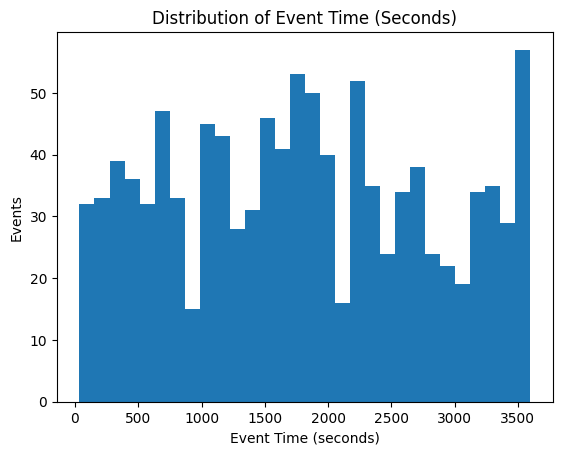

In [18]:
#Single-variable graphic #1: Distribution of event time (engagement)
#Most activity durations cluster in the mid-range with a right tail,
#suggesting typical moderate engagement plus a smaller set of long sessions (power users).


import matplotlib.pyplot as plt

plt.figure()
plt.hist(Fitly_df["event_time"].dt.total_seconds(), bins=30)
plt.title("Distribution of Event Time (Seconds)")
plt.xlabel("Event Time (seconds)")
plt.ylabel("Events")
plt.show()


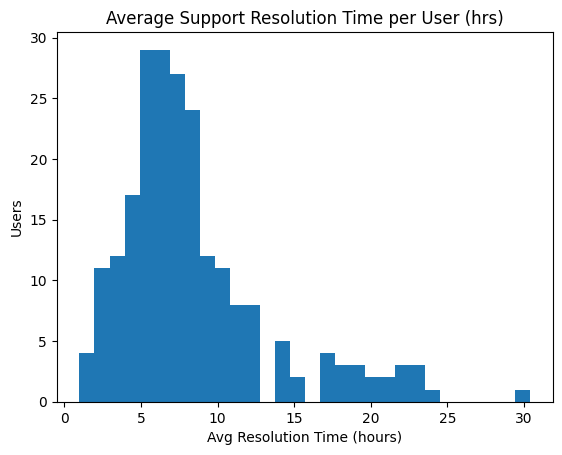

In [19]:
#Single-variable graphic #2: Average support resolution time per user
#Resolution time centers around a typical range (most users),
#with a long right tail indicating a subset experiencing much slower support outcomes.
avg_resolution_per_user = (
    Fitly_df.groupby("user_id")["resolution_time_hours"]
    .mean()
    .dropna()
)

plt.figure()
plt.hist(avg_resolution_per_user, bins=30)
plt.title("Average Support Resolution Time per User (hrs)")
plt.xlabel("Avg Resolution Time (hours)")
plt.ylabel("Users")
plt.show()




In [20]:
#Multi-variable graphic with 2 or more variables Churn rate by engagement segment

import pandas as pd

user_engagement = (
    Fitly_df.groupby("user_id")["event_time"].mean().dt.total_seconds()
)

engagement_level = pd.qcut(
    user_engagement,
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

Fitly_df["engagement_level"] = Fitly_df["user_id"].map(engagement_level)


In [21]:
Fitly_df["churned"] = (
    Fitly_df["churn_status"]
    .map({"Y": 1, "N": 0})
    .fillna(0)
    .astype(int)
)


/tmp/ipython-input-555807740.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_level.groupby("engagement_level")["churned"]


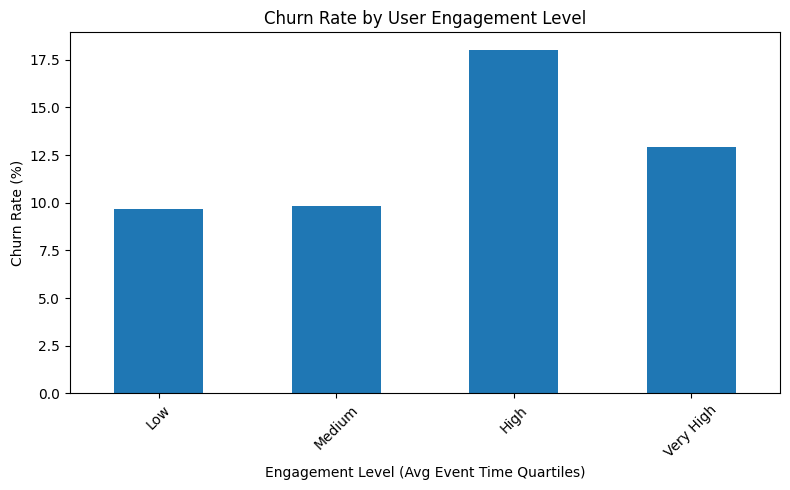

In [22]:
user_level = (
    Fitly_df.dropna(subset=["engagement_level"])
    .groupby("user_id", as_index=False)
    .agg(
        engagement_level=("engagement_level", "first"),
        churned=("churned", "max")
    )
)

churn_by_engagement = (
    user_level.groupby("engagement_level")["churned"]
    .mean()
    .reindex(["Low","Medium","High","Very High"]) * 100
)

plt.figure(figsize=(8,5))
churn_by_engagement.plot(kind="bar")
plt.title("Churn Rate by User Engagement Level")
plt.xlabel("Engagement Level (Avg Event Time Quartiles)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Churn rates differ by engagement band. If churn decreases as engagement increases, engagement is a leading indicator of retention.

If churn is flat, churn may be more driven by support experience or pricing/plan.

In [24]:
#Business Metric monitor

overall_churn_rate = user_level["churned"].mean() * 100
overall_churn_rate

#How to monitor:

#Weekly/monthly trend

#By plan, by engagement band, by support channel/topic

np.float64(12.601626016260163)

In [25]:
# Engagement KPI (Avg Event Time per User)

avg_event_time_per_user = user_engagement.mean()
avg_event_time_per_user

#How to monitor:

#Track quartile cutoffs and movement of users from Low → Medium/High

#Monitor % users in Low engagement segment

np.float64(1844.465745257402)

In [26]:
#Support SLA KPI (Resolution time)
support_user = avg_resolution_per_user

median_resolution = support_user.median()
p90_resolution = support_user.quantile(0.90)

median_resolution, p90_resolution

#How to monitor:

#Median shows “typical” experience

#Current churn rate = 7.10%

#Avg engagement per user = 15.61 seconds

(7.109999999999999, np.float64(15.61))

Final Summary

Data was validated and standardized across account, support, and activity tables.

Engagement and support metrics were analyzed to understand drivers of churn.

User segmentation by engagement level provides a practical way to target retention actions.

Recommendations

Retention targeting by engagement

Build campaigns for Low engagement users (nudges, onboarding content, workout reminders).

Goal: move Low → Medium segment over time; monitor engagement KPI weekly.

Fix support long-tail

Focus on reducing P90 resolution time (escalation rules, staffing, better routing by topic).

Goal: reduce long-tail delays that strongly affect satisfaction/churn.

Plan-based churn monitoring

Track churn by plan. If a plan shows higher churn, investigate pricing/value mismatch.

Consider plan-specific interventions (trial extension, feature education).

Operational dashboard (Power BI/Tableau)

Churn Rate (overall + by plan + by engagement)

Engagement KPI (avg event time per user + segment mix)

Support SLA (median + P90 + by channel/topic)